In [1]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [2]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]

    gamma,xi,damping,log_mean,log_std = theta
    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _,loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


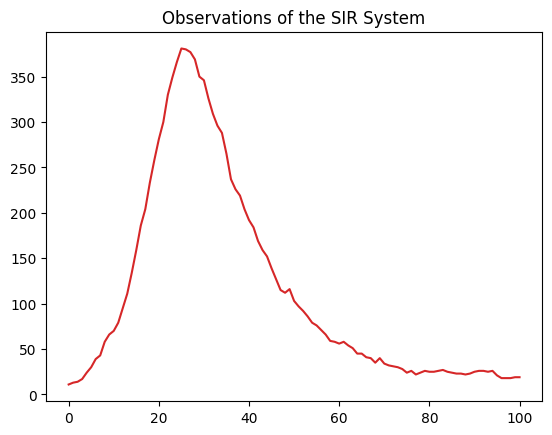

In [3]:
theta = (0.1, 1 / 90, 1 / 35, jnp.log(0.35), 0.2)
delta_t = 1.0
days = 100
rng_key = jax.random.key(0)
t_range = jnp.arange(0,days + delta_t, delta_t)

num_models = 1_000
keys = jax.random.split(rng_key, num_models)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=20, shape=(num_models,))

x0 = jnp.full(shape=(num_models, 3), fill_value=jnp.array([1000, 0, 0]))

x0 = x0.at[:, 0].set(x0[:, 0] - I_x0)
x0 = x0.at[:, 1].set(x0[:, 1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, shape=(num_models,), minval=0.1, maxval=0.5)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

full_state = jax.vmap(model, in_axes=(0, None, 0, None))(
    x0, theta, keys, t_range
)

observations = full_state[0, :, 1]

plt.title("Observations of the SIR System")
plt.plot(
        t_range,
        observations.T,
        color="tab:red",
)
plt.show()

In [4]:
def likelihood(particles,observation): 
    return jax.scipy.stats.poisson.logpmf(observation, mu = particles[:,1])

In [5]:
from algorithms.smc import particle_filter 

pf_init_key, rng_key = jax.random.split(rng_key)

num_particles = 100

particles = jnp.full(
    shape=(num_particles, 3), fill_value=jnp.array([1000, 0, 0])
)

particles_I = jax.random.randint(
    pf_init_key, shape=(num_particles), minval=0, maxval=20
)

particles = particles.at[:, 1].set(particles[:, 1] + particles_I)
particles = particles.at[:, 0].set(particles[:, 0] - particles_I)

beta_init_key, rng_key = jax.random.split(rng_key)

particle_betas = jax.random.uniform(
    beta_init_key, shape=(num_particles, 1), minval=0.1, maxval=0.5
)
particles = jnp.concatenate((particles, jnp.log(particle_betas)), axis=-1)

pf_key,rng_key = jax.random.split(rng_key)
particles,weights = particle_filter(model,observations,particles,pf_key,likelihood,theta,jnp.linspace(0,delta_t,2))

/tmp/ipykernel_532653/591111783.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


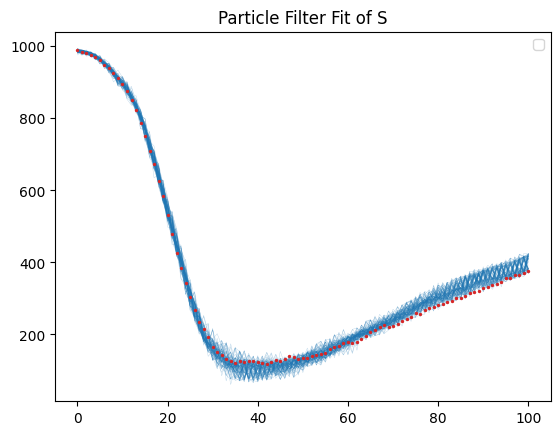

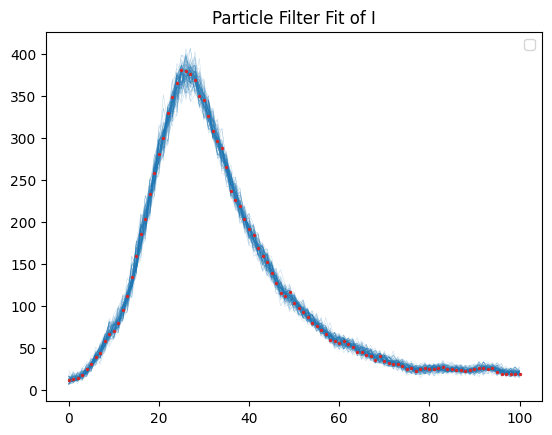

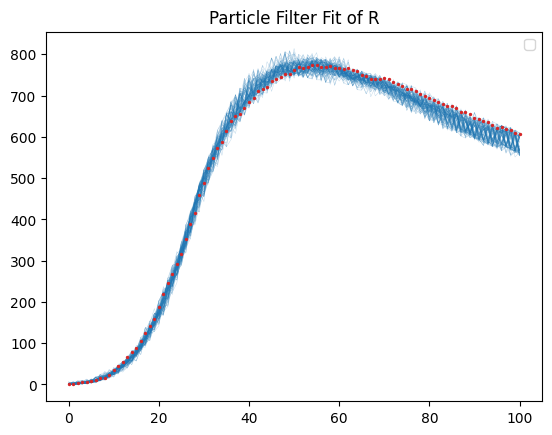

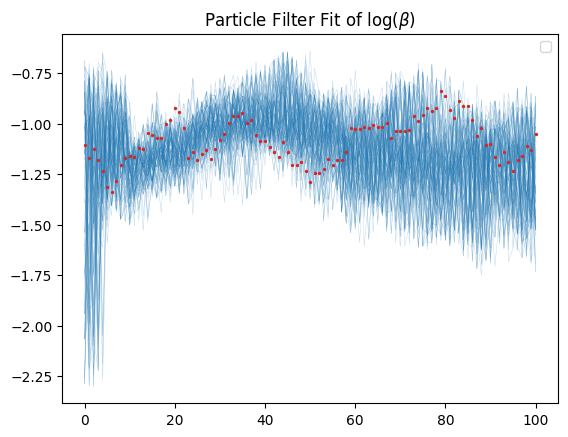

In [ ]:
states = ['S','I','R','$\\log(\\beta)$']
for i,state in enumerate(states): 
    plt.title(f"Particle Filter Fit of {state}")
    plt.scatter(
        t_range,
        full_state[0,:,i].T,
        color="tab:red",
        s = 2.0,
        zorder=100
    )
    plt.plot(
        t_range,
        particles[:, :, i].T,
        lw=0.3,
        alpha = 0.3,
        color="tab:blue",
    )
    plt.legend()
    plt.show()